In [3]:
!pip install vaderSentiment

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 126.0/126.0 kB 3.2 MB/s eta 0:00:00


In [4]:
# ============================================================
# AI-POWERED SOCIAL MEDIA STRATEGY
# Python Hands-on Demonstration
#
# Dataset:
#   social_media_strategy_2000.csv
#
# Flow:
#   1. Business baseline
#   2. Data quality
#   3. Text cleaning
#   4. Sentiment analysis
#   5. Sentiment by campaign/platform
#   6. Topic/theme analysis
#   7. Engagement analysis
#   8. Sentiment trends
#   9. Strategic insight
#
# Install first if required:
#
# pip install pandas numpy matplotlib seaborn nltk vaderSentiment
# ============================================================


# ============================================================
# 0. IMPORT LIBRARIES
# ============================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import re

from collections import Counter
from vaderSentiment.vaderSentiment import SentimentIntensityAnalyzer


# ============================================================
# SETTINGS
# ============================================================

pd.set_option("display.max_columns", None)
pd.set_option("display.width", 120)

sns.set_theme(style="whitegrid")

In [5]:
# ============================================================
# 1. LOAD THE DATA
# ============================================================

print("=" * 70)
print("1. LOADING SOCIAL MEDIA DATA")
print("=" * 70)

df = pd.read_csv("/content/social_posts.csv")

print("\nFirst 5 records:")
print(df.head())

print("\nDataset shape:")
print(df.shape)

print("\nColumns:")
print(df.columns.tolist())

1. LOADING SOCIAL MEDIA DATA

First 5 records:
   post_id              date   platform                                               text  engagement  likes  \
0  SM00572  2026-07-01 00:42    YouTube  Really impressed with the voice control on my ...          17      9   
1  SM00580  2026-07-01 00:54  Instagram  Comparing NovaPhone X mainly on health trackin...          28     18   
2  SM00645  2026-07-01 02:56   Facebook  Please resolve the delivery promise. This is a...          25     16   
3  SM01527  2026-07-01 04:03    YouTube  Great job on the late delivery. This upgrade f...          32     21   
4  SM01180  2026-07-01 05:00     Reddit  Update: I received information about the suppo...           8      1   

   comments  shares  views      product         campaign         market  language       author_type  verified_account  
0         1       2    124  NovaPhone X  Festival Launch    India-North   English          Prospect                 0  
1         5       0    216  NovaPh

In [6]:
# ============================================================
# BUSINESS QUESTION
# ============================================================

print("\nBUSINESS QUESTION:")
print("How much social-media conversation are we dealing with?")


# ============================================================
# 2. DATA QUALITY
# ============================================================

print("\n" + "=" * 70)
print("2. DATA QUALITY CHECK")
print("=" * 70)

print("\nData types:")
print(df.dtypes)

print("\nMissing values:")
print(df.isnull().sum())

print("\nDuplicate rows:")
print(df.duplicated().sum())

print("\nUnique platforms:")
print(df["platform"].value_counts(dropna=False))

print("\nCampaign distribution:")
print(df["campaign"].value_counts(dropna=False))


BUSINESS QUESTION:
How much social-media conversation are we dealing with?

2. DATA QUALITY CHECK

Data types:
post_id             object
date                object
platform            object
text                object
engagement           int64
likes                int64
comments             int64
shares               int64
views                int64
product             object
campaign            object
market              object
language            object
author_type         object
verified_account     int64
dtype: object

Missing values:
post_id               0
date                  0
platform              0
text                  0
engagement            0
likes                 0
comments              0
shares                0
views                 0
product               0
campaign            392
market                0
language              0
author_type           0
verified_account      0
dtype: int64

Duplicate rows:
0

Unique platforms:
platform
Instagram    383
Reddit       29

In [7]:
# ============================================================
# BUSINESS DISCUSSION
# ============================================================

print("\nBUSINESS QUESTION:")
print("Can we trust the data before making marketing decisions?")

print("""
Things to check:
- Missing values
- Duplicate records
- Incorrect data types
- Unexpected categories
- Empty comments
""")


# ============================================================
# 3. CLEAN THE DATA
# ============================================================

print("\n" + "=" * 70)
print("3. CLEANING THE DATA")
print("=" * 70)

# Remove duplicate records
df = df.drop_duplicates()

# Convert date
df["date"] = pd.to_datetime(df["date"], errors="coerce")

# Remove records where comment is missing
df = df.dropna(subset=["text"])

# Fill categorical missing values
df["platform"] = df["platform"].fillna("Unknown")
df["campaign"] = df["campaign"].fillna("Unknown")
df["product"] = df["product"].fillna("Unknown")

print("Dataset after cleaning:")
print(df.shape)



BUSINESS QUESTION:
Can we trust the data before making marketing decisions?

Things to check:
- Missing values
- Duplicate records
- Incorrect data types
- Unexpected categories
- Empty comments


3. CLEANING THE DATA
Dataset after cleaning:
(1600, 15)


In [8]:
# ============================================================
# BUSINESS QUESTION
# ============================================================

print("""
BUSINESS QUESTION:

What information do we have about our social-media audience
and conversations?

We have:
- What people say
- Where they say it
- What product they discuss
- Which campaign they respond to
- Which market they belong to
- Who is posting
- How much engagement they generate
""")


# ============================================================
# 4. DATA QUALITY CHECK
# ============================================================

print("\n" + "=" * 70)
print("2. DATA QUALITY CHECK")
print("=" * 70)

print("\nData types:")
print(df.dtypes)

print("\nMissing values:")
print(df.isnull().sum())

print("\nDuplicate rows:")
print(df.duplicated().sum())

print("\nDuplicate post IDs:")
print(df["post_id"].duplicated().sum())


# ============================================================
# UNIQUE VALUES
# ============================================================

print("\nPlatforms:")
print(df["platform"].value_counts(dropna=False))

print("\nProducts:")
print(df["product"].value_counts(dropna=False))

print("\nCampaigns:")
print(df["campaign"].value_counts(dropna=False))

print("\nMarkets:")
print(df["market"].value_counts(dropna=False))

print("\nLanguages:")
print(df["language"].value_counts(dropna=False))

print("\nAuthor types:")
print(df["author_type"].value_counts(dropna=False))

print("\nVerified accounts:")
print(df["verified_account"].value_counts(dropna=False))


BUSINESS QUESTION:

What information do we have about our social-media audience
and conversations?

We have:
- What people say
- Where they say it
- What product they discuss
- Which campaign they respond to
- Which market they belong to
- Who is posting
- How much engagement they generate


2. DATA QUALITY CHECK

Data types:
post_id                     object
date                datetime64[ns]
platform                    object
text                        object
engagement                   int64
likes                        int64
comments                     int64
shares                       int64
views                        int64
product                     object
campaign                    object
market                      object
language                    object
author_type                 object
verified_account             int64
dtype: object

Missing values:
post_id             0
date                0
platform            0
text                0
engagement          0
likes

In [9]:
# ============================================================
# 5. CLEAN THE DATA
# ============================================================

print("\n" + "=" * 70)
print("3. DATA CLEANING")
print("=" * 70)

# Remove duplicate rows
df = df.drop_duplicates()

# Remove duplicate post IDs
df = df.drop_duplicates(
    subset="post_id"
)

# Convert date
df["date"] = pd.to_datetime(
    df["date"],
    errors="coerce"
)

# Handle missing categorical values
categorical_columns = [
    "platform",
    "product",
    "campaign",
    "market",
    "language",
    "author_type"
]

for col in categorical_columns:
    df[col] = df[col].fillna("Unknown")

# Handle missing text
df["text"] = df["text"].fillna("")

# Convert verified account
df["verified_account"] = (
    df["verified_account"]
    .astype(str)
    .str.lower()
    .map({
        "true": True,
        "false": False,
        "1": True,
        "0": False,
        "yes": True,
        "no": False
    })
)

print("Dataset after cleaning:")
print(df.shape)



3. DATA CLEANING
Dataset after cleaning:
(1600, 15)



4. WHERE IS THE CONVERSATION HAPPENING?

Posts by platform:
platform
Instagram    383
Reddit       293
YouTube      282
X            266
LinkedIn     193
Facebook     183
Name: count, dtype: int64


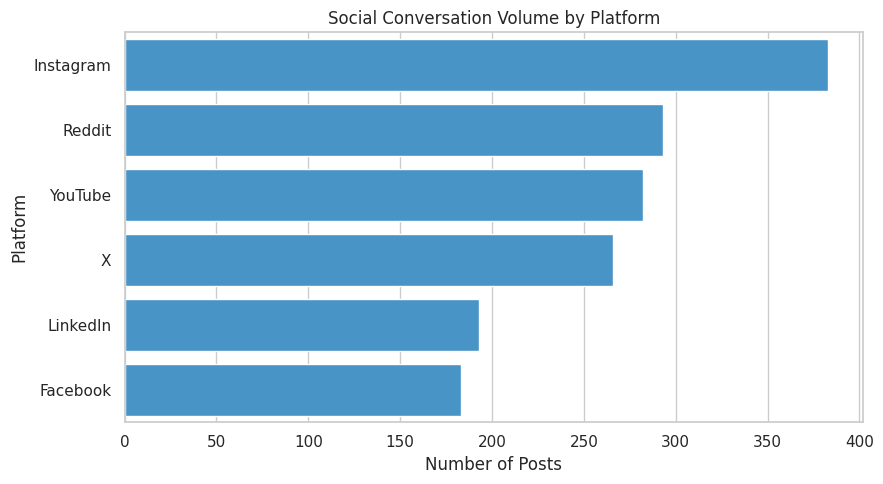

In [10]:
# ============================================================
# 6. SOCIAL MEDIA VOLUME
# ============================================================

print("\n" + "=" * 70)
print("4. WHERE IS THE CONVERSATION HAPPENING?")
print("=" * 70)

platform_volume = (
    df["platform"]
    .value_counts()
)

print("\nPosts by platform:")
print(platform_volume)


plt.figure(figsize=(9, 5))

sns.barplot(
    x=platform_volume.values,
    y=platform_volume.index,
    color="#3498db"
)

plt.title("Social Conversation Volume by Platform")
plt.xlabel("Number of Posts")
plt.ylabel("Platform")

plt.tight_layout()
plt.show()



5. WHICH MARKETS ARE TALKING?
market
India-North      348
India-West       325
India-Central    317
India-South      315
India-East       295
Name: count, dtype: int64


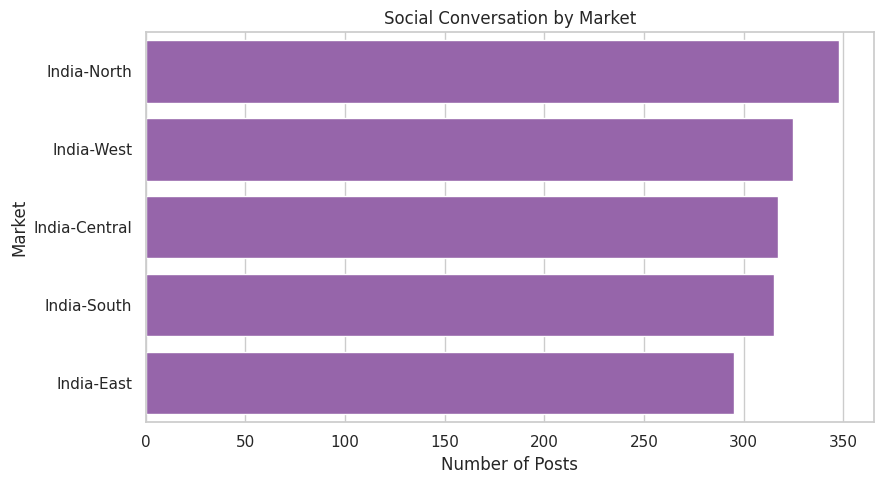

In [11]:
# ============================================================
# 7. MARKET ANALYSIS
# ============================================================

print("\n" + "=" * 70)
print("5. WHICH MARKETS ARE TALKING?")
print("=" * 70)

market_volume = (
    df["market"]
    .value_counts()
)

print(market_volume)


plt.figure(figsize=(9, 5))

sns.barplot(
    x=market_volume.values,
    y=market_volume.index,
    color="#9b59b6"
)

plt.title("Social Conversation by Market")
plt.xlabel("Number of Posts")
plt.ylabel("Market")

plt.tight_layout()
plt.show()

In [12]:
# ============================================================
# BUSINESS QUESTION
# ============================================================

print("""
BUSINESS QUESTION:

Does conversation volume automatically mean a market is valuable?

No.

We need to combine:
    Volume
    +
    Engagement
    +
    Sentiment
    +
    Business objectives
""")


# ============================================================
# 8. TEXT PREPROCESSING
# ============================================================

print("\n" + "=" * 70)
print("6. TEXT PREPROCESSING")
print("=" * 70)


def clean_text(text):

    text = str(text)

    # Lowercase
    text = text.lower()

    # Remove URLs
    text = re.sub(
        r"http\S+|www\S+",
        "",
        text
    )

    # Remove mentions
    text = re.sub(
        r"@\w+",
        "",
        text
    )

    # Remove hashtag symbol
    text = re.sub(
        r"#",
        "",
        text
    )

    # Remove extra whitespace
    text = re.sub(
        r"\s+",
        " ",
        text
    ).strip()

    return text


df["clean_text"] = df["text"].apply(
    clean_text
)

print("\nOriginal text:")
print(df["text"].iloc[0])

print("\nCleaned text:")
print(df["clean_text"].iloc[0])


BUSINESS QUESTION:

Does conversation volume automatically mean a market is valuable?

No.

We need to combine:
    Volume
    +
    Engagement
    +
    Sentiment
    +
    Business objectives


6. TEXT PREPROCESSING

Original text:
Really impressed with the voice control on my NovaPhone X. Smooth experience!

Cleaned text:
really impressed with the voice control on my novaphone x. smooth experience!


In [13]:
# ============================================================
# 9. SENTIMENT ANALYSIS
# ============================================================

print("\n" + "=" * 70)
print("7. SENTIMENT ANALYSIS")
print("=" * 70)

print("""
BUSINESS QUESTION:

What is the emotional tone of the conversation?
""")


analyzer = SentimentIntensityAnalyzer()


def sentiment_score(text):

    result = analyzer.polarity_scores(
        str(text)
    )

    return result["compound"]


df["sentiment_score"] = (
    df["text"]
    .apply(sentiment_score)
)


def sentiment_label(score):

    if score >= 0.05:
        return "Positive"

    elif score <= -0.05:
        return "Negative"

    else:
        return "Neutral"


df["sentiment"] = (
    df["sentiment_score"]
    .apply(sentiment_label)
)


print("\nSentiment distribution:")

print(
    df["sentiment"]
    .value_counts()
)


7. SENTIMENT ANALYSIS

BUSINESS QUESTION:

What is the emotional tone of the conversation?


Sentiment distribution:
sentiment
Positive    890
Neutral     361
Negative    349
Name: count, dtype: int64



Sentiment percentage:
sentiment
Positive    55.62
Neutral     22.56
Negative    21.81
Name: proportion, dtype: float64


/tmp/ipykernel_4935/2823100266.py:31: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(


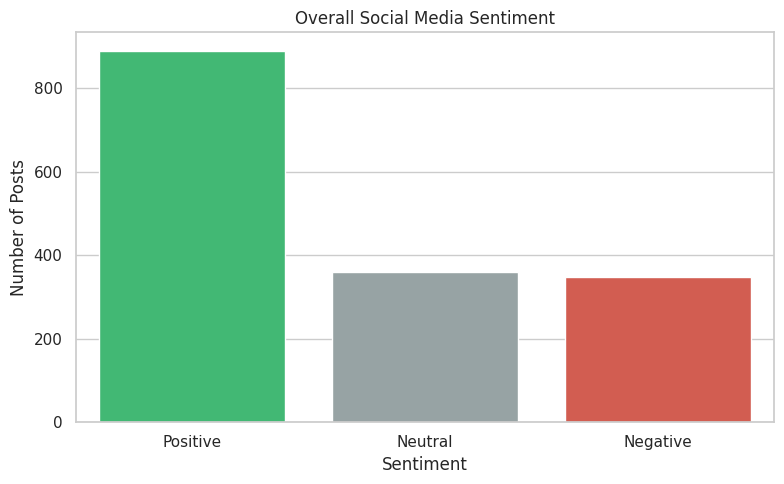

In [14]:
# ============================================================
# 10. SENTIMENT PERCENTAGE
# ============================================================

sentiment_percentage = (
    df["sentiment"]
    .value_counts(
        normalize=True
    )
    .mul(100)
    .round(2)
)

print("\nSentiment percentage:")

print(sentiment_percentage)


# ============================================================
# VISUALIZATION
# ============================================================

plt.figure(figsize=(8, 5))

sentiment_order = [
    "Positive",
    "Neutral",
    "Negative"
]

sns.countplot(
    data=df,
    x="sentiment",
    order=sentiment_order,
    palette={
        "Positive": "#2ecc71",
        "Neutral": "#95a5a6",
        "Negative": "#e74c3c"
    }
)

plt.title("Overall Social Media Sentiment")
plt.xlabel("Sentiment")
plt.ylabel("Number of Posts")

plt.tight_layout()
plt.show()



8. SENTIMENT BY PLATFORM
sentiment  Negative  Neutral  Positive
platform                              
Facebook       21.9     22.4      55.7
Instagram      22.7     19.6      57.7
LinkedIn       23.3     23.3      53.4
Reddit         20.8     24.9      54.3
X              22.2     21.4      56.4
YouTube        20.2     24.8      55.0


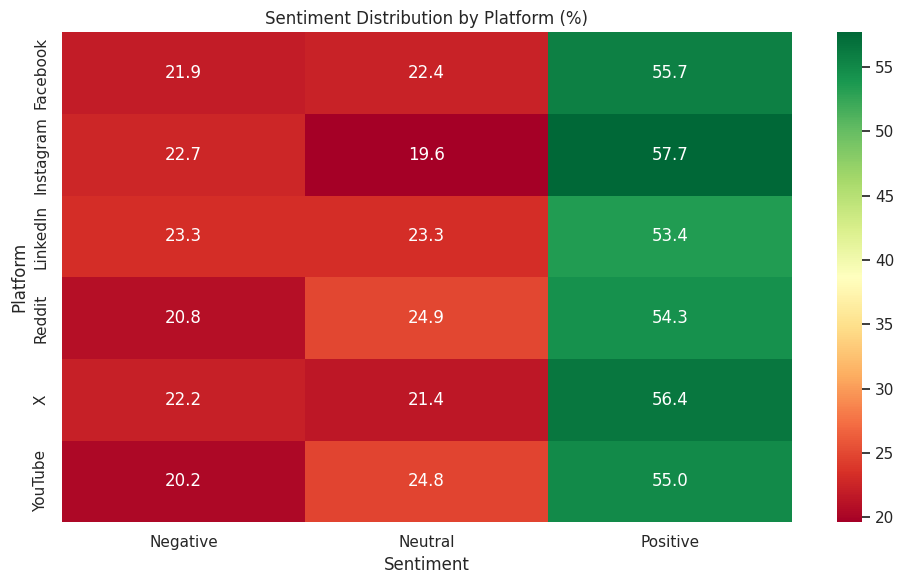

In [15]:
# ============================================================
# 11. SENTIMENT BY PLATFORM
# ============================================================

print("\n" + "=" * 70)
print("8. SENTIMENT BY PLATFORM")
print("=" * 70)

platform_sentiment = pd.crosstab(
    df["platform"],
    df["sentiment"],
    normalize="index"
).mul(100).round(1)

print(platform_sentiment)


plt.figure(figsize=(10, 6))

sns.heatmap(
    platform_sentiment,
    annot=True,
    fmt=".1f",
    cmap="RdYlGn"
)

plt.title(
    "Sentiment Distribution by Platform (%)"
)

plt.xlabel("Sentiment")
plt.ylabel("Platform")

plt.tight_layout()
plt.show()

In [16]:
# ============================================================
# 12. SENTIMENT BY MARKET
# ============================================================

print("\n" + "=" * 70)
print("9. SENTIMENT BY MARKET")
print("=" * 70)

market_sentiment = pd.crosstab(
    df["market"],
    df["sentiment"],
    normalize="index"
).mul(100).round(1)

print(market_sentiment)


9. SENTIMENT BY MARKET
sentiment      Negative  Neutral  Positive
market                                    
India-Central      23.0     19.2      57.7
India-East         22.4     25.4      52.2
India-North        20.1     25.6      54.3
India-South        22.5     18.4      59.0
India-West         21.2     24.0      54.8


## TF-IDF Vectorizer

In [17]:
# ============================================================
# TRUST THE MODEL?
# ============================================================

print("="*70)
print("CAN WE TRUST THE ABOVE ANALYSIS ?")
print("="*70)

challenge_pattern = (
    r"great, another|"
    r"fantastic service|"
    r"amazing how|"
    r"love spending|"
    r"\blove\b.*\bbut\b|"
    r"\bgood overall\b.*although|"
    r"\bsick\b|"
    r"\bslaps\b|"
    r"\bfire\b"
)

challenge_cases = df[
    df["text"].str.contains(
        challenge_pattern,
        case=False,
        regex=True,
        na=False
    )
]

print(
    challenge_cases[
        ["text","sentiment_score","sentiment"]
    ].head(15)
)

print("""
Discussion:
- Sarcasm
- Slang
- Mixed sentiment
- Context dependence
- Human validation
""")

CAN WE TRUST AI?
                                                  text  sentiment_score sentiment
9    Great, another delivery delay. Exactly what cu...           0.4215  Positive
10   Amazing how the app usability keeps getting wo...           0.1779  Positive
22   The product is good overall, although the soun...           0.7096  Positive
24   The product is good overall, although the inte...           0.7096  Positive
25   This delivery promise is fire. Did not expect ...           0.5065  Positive
27   Fantastic service: still dealing with the app ...           0.5574  Positive
28   Fantastic service: still dealing with the trac...           0.2960  Positive
42   Fantastic service: still dealing with the deli...           0.7096  Positive
43   AirBeat Pro absolutely slaps when it comes to ...           0.0000   Neutral
46   The product is good overall, although the trac...           0.7096  Positive
47   The tracking update is sick, honestly a solid ...           0.0772  Positive

response                0.065464
experience              0.063826
frustrating waiting     0.061912
proper response         0.061912
waiting                 0.061912
waiting proper          0.061912
proper                  0.061912
frustrating             0.061912
acceptable              0.059761
difficult               0.059761
experience difficult    0.059761
disappointed            0.054343
needs fixing            0.054343
needs                   0.054343
fixing                  0.054343
delivery                0.043939
novaphone               0.032648
tracking                0.031236
novaphone needs         0.030657
quality                 0.030281
dtype: float64


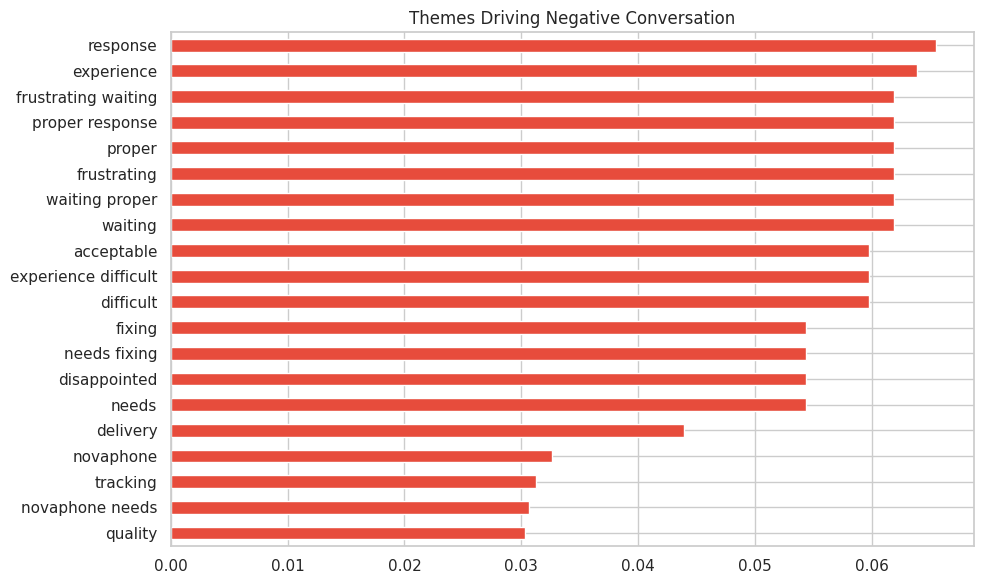

In [19]:
# ============================================================
# THEME DISCOVERY USING TF-IDF
# ============================================================

from sklearn.feature_extraction.text import TfidfVectorizer

negative_posts = (
    df[df["sentiment"]=="Negative"]
    ["clean_text"]
)

vectorizer = TfidfVectorizer(
    stop_words="english",
    ngram_range=(1,2),
    min_df=3,
    max_df=0.90
)

X = vectorizer.fit_transform(
    negative_posts
)

terms = pd.Series(
    X.mean(axis=0).A1,
    index=vectorizer.get_feature_names_out()
)

top_terms = (
    terms
    .sort_values(ascending=False)
    .head(20)
)

print(top_terms)

plt.figure(figsize=(10,6))
top_terms.sort_values().plot(
    kind="barh",
    color="#e74c3c"
)
plt.title(
    "Themes Driving Negative Conversation"
)
plt.tight_layout()
plt.show()

## Spike Detection

CAMPAIGN SPIKE DETECTION


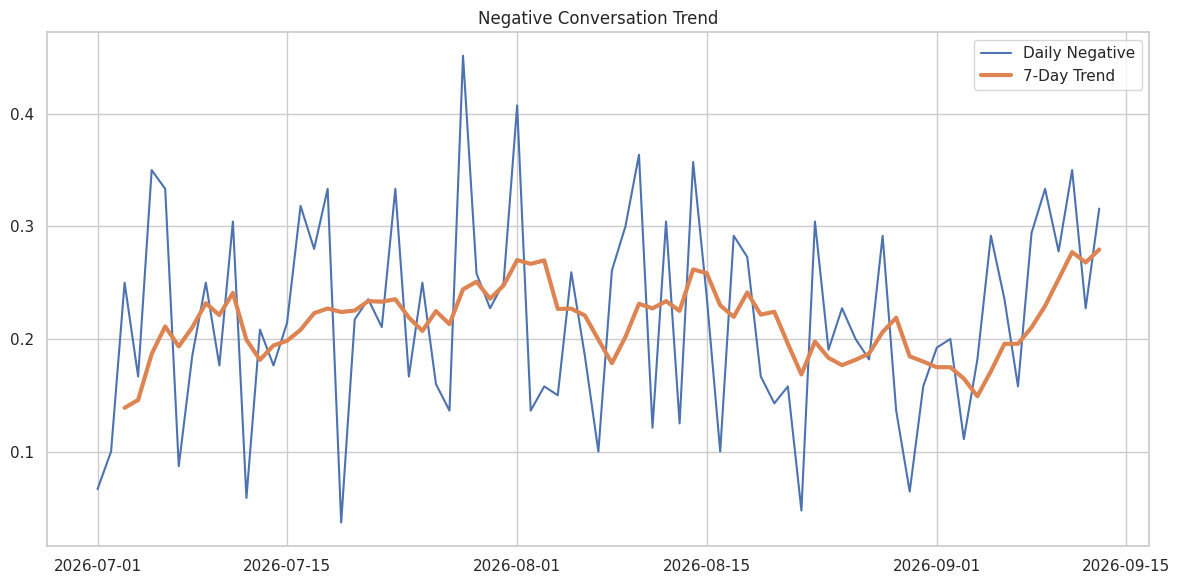

In [21]:
# ============================================================
# CAMPAIGN SPIKE DETECTION
# ============================================================

print("="*70)
print("CAMPAIGN SPIKE DETECTION")
print("="*70)

daily = (
    df.groupby(
        [
            df["date"].dt.date,
            "sentiment"
        ]
    )
    .size()
    .unstack(fill_value=0)
)

daily["total"] = daily.sum(axis=1)

daily["negative_share"] = (
    daily["Negative"]
    / daily["total"]
)

daily["negative_7d"] = (
    daily["negative_share"]
    .rolling(7,min_periods=3)
    .mean()
)

plt.figure(figsize=(12,6))

plt.plot(
    daily.index,
    daily["negative_share"],
    label="Daily Negative"
)

plt.plot(
    daily.index,
    daily["negative_7d"],
    linewidth=3,
    label="7-Day Trend"
)

plt.legend()

plt.title(
    "Negative Conversation Trend"
)

plt.tight_layout()
plt.show()

## Executive Decisions

In [33]:

# ============================================================
# 27. PRODUCT × CAMPAIGN
# ============================================================

print("\n" + "=" * 70)
print("24. PRODUCT × CAMPAIGN")
print("=" * 70)

product_campaign = pd.pivot_table(
    df,
    index="product",
    columns="campaign",
    values="engagement",
    aggfunc="mean"
).round(2)

print(product_campaign)



24. PRODUCT × CAMPAIGN
campaign        Always-on  Creator Collab  Festival Launch  Service Update  Unknown
product                                                                            
AirBeat Pro         23.31           22.25            23.55           25.91    28.78
FitPulse Watch      24.53           26.37            25.36           21.82    23.59
HomeHub Mini        26.78           25.09            24.85           21.78    25.20
NovaPhone X         22.56           21.68            23.62           20.54    23.98


In [23]:
campaign_negative = (
    df.groupby("campaign")["sentiment"]
      .apply(
          lambda x: (x == "Negative").mean()
      )
      .sort_values(ascending=False)
)

top_campaign = campaign_negative.idxmax()

negative_rate = campaign_negative.max()

In [25]:
# ============================================================
# EXECUTIVE DECISION BRIEF
# ============================================================

top_campaign = (
    campaign_negative
    .idxmax()
)

campaign_posts = df[
    df["campaign"] == top_campaign
]

negative_rate = (
    campaign_posts["sentiment"]
    == "Negative"
).mean()

top_examples = (
    campaign_posts
    .sort_values(
        "engagement",
        ascending=False
    )
    .head(3)["text"]
)

print("="*70)
print("EXECUTIVE DECISION BRIEF")
print("="*70)

print(f"Signal: {top_campaign} shows the highest negative sentiment.")

print(
    f"Negative Share: {negative_rate:.1%}"
)

print(
    "\\nBusiness Meaning:"
)

print(
    "Customer expectations may not be aligned with campaign outcomes."
)

print(
    "\\nRecommended Action:"
)

print(
    "Validate customer concerns and investigate dominant themes."
)

print(
    "\\nRepresentative Posts:"
)

for p in top_examples:
    print("-",p)

EXECUTIVE DECISION BRIEF
Signal: Festival Launch shows the highest negative sentiment.
Negative Share: 23.6%
\nBusiness Meaning:
Customer expectations may not be aligned with campaign outcomes.
\nRecommended Action:
Validate customer concerns and investigate dominant themes.
\nRepresentative Posts:
- Great, another refund help. Exactly what customers needed.
- The late delivery is frustrating. Still waiting for a proper response. Please jaldi resolve karo.
- Comparing AirBeat Pro mainly on delivery promise. Any first-hand feedback?
